In [1]:
from platosim.simfile import SimFile
from platosim.simulation import Simulation
from platosim.validation import switchOffAllEffects
import os
import matplotlib.pyplot as plt
import numpy as np

# Nominal operating temperature

In [2]:
sim = Simulation("ElectronicOffset")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# Single-pixel exposures

numExposures = 100
sim["ObservingParameters/NumExposures"] = numExposures
sim["SubField/NumRows"] = 1
sim["SubField/NumColumns"] = 1

In [3]:
deltaTemperature = 10
time = np.array([0, (numExposures - 1) * 25])

temperature = np.array([sim["FEE/NominalOperatingTemperature"], sim["FEE/NominalOperatingTemperature"] + deltaTemperature])

sim["FEE/Temperature"] = "FromFile"
temperatureFilename = os.environ["PLATO_WORKDIR"] + "temperature.txt"
sim["FEE/TemperatureFileName"] = temperatureFilename

np.savetxt(temperatureFilename, np.c_[time, temperature])

sim["CCD/IncludeQuantisation"] = "yes"
sim["FEE/Gain/Stability"] = 0

output = sim.run(removeOutputFile = True)
print(temperature)


2020-05-20 14:56:20 WARNING Simulation: no information about detected stars to write to HDF5
2020-05-20 14:56:20 WARNING Camera: No star positions to write to HDF5 file.

[210.15 220.15]


In [4]:
offset = np.array([])

for exposure in range(numExposures):
    
    output.getImage(exposure)
    offset = np.append(offset, output.getImage(exposure)[0][0])

In [5]:
exposureTime = output.getInputParameter("ObservingParameters", "CycleTime") - sim.getReadoutTime()[0]
expectedSkyBackground = output.getInputParameter("Sky", "SkyBackground") * exposureTime * output.getInputParameter("Telescope/TransmissionEfficiency", "BOL") * sim["FEE/Gain/RefValueLeft"] * sim["CCD/Gain/RefValueLeft"]

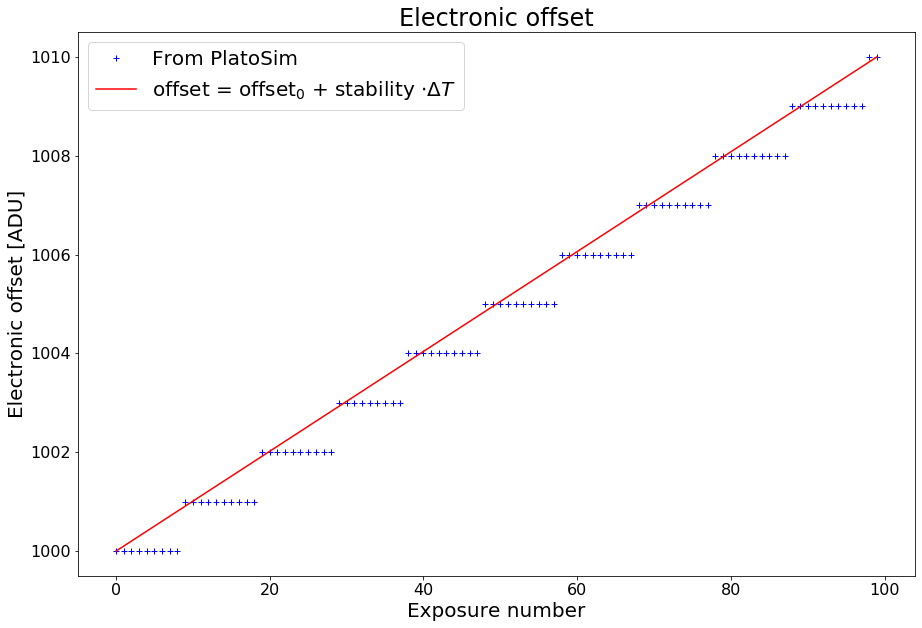

In [7]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

# plt.plot(offset, "b+", label="From PlatoSim")
plt.plot(np.round(offset - expectedSkyBackground), "b+", label="From PlatoSim")



##########################################################
# Linear decrease in FEE gain with increase in temperature
##########################################################

feeSlope = (temperature[-1] - temperature[0]) / (numExposures - 1) * sim["FEE/ElectronicOffset/Stability"]
exposures = np.arange(0, numExposures)
plt.plot(sim["FEE/ElectronicOffset/RefValue"] + feeSlope * exposures, "r", label = "offset = offset$_0$ + stability $\\cdot \\Delta T$")

########
# Layout
########

plt.title("Electronic offset", fontsize = 24)
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("Electronic offset [ADU]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)